# Educational Knowledge Graph Project

### Building Structured Knowledge from Unstructured Data

**Group:** Group 7  
**Instructor:** Jiaxin Du

In [17]:
import os

# Setup for Google Colab:
# Clone the repository if the 'data' folder is not found
# This ensures the notebook works both locally and in Colab
if not os.path.exists("data"):
    !git clone https://github.com/Bless01/KDD_Group7.git
    %cd KDD_Group7

In [18]:
!python -m pip install networkx matplotlib scikit-learn pandas

In [19]:
import os
os.environ["MPLCONFIGDIR"] = os.path.abspath("./mplconfig")

%matplotlib inline

import re
import itertools
from collections import Counter

import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
data_folder = "data"
documents = []

# Ensure the data folder exists before trying to list its contents
if os.path.exists(data_folder) and os.path.isdir(data_folder):
    for file_name in os.listdir(data_folder):
        if file_name.endswith(".txt"):
            with open(os.path.join(data_folder, file_name), "r", encoding="utf-8") as f:
                documents.append(f.read())
else:
    print(f"Warning: The folder '{data_folder}' does not exist or is not a directory. No documents loaded.")


print("Number of documents loaded:", len(documents))
if documents:
    for i, doc in enumerate(documents, 1):
        print(f"\nDocument {i} preview:")
        print(doc[:150])
else:
    print("No documents available for preview.")

Number of documents loaded: 5

Document 1 preview:
Cybersecurity

Cybersecurity (also known as computer security or IT security) is the practice of protecting computer systems, networks, and data from 

Document 2 preview:
Data Science

Data science is an interdisciplinary field that focuses on extracting useful knowledge and insights from data. It combines techniques fr

Document 3 preview:
Computer Science

Computer science is the study of computation, information, and automation. It focuses on how computers process data, solve problems,

Document 4 preview:
Health Informatics

Health informatics is the use of computer science and information technology to improve healthcare systems. It focuses on managing

Document 5 preview:
Machine Learning

Machine learning is a branch of artificial intelligence that focuses on creating systems that can learn from data and improve their 


In [21]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s.]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

cleaned_docs = [clean_text(doc) for doc in documents]

print("Cleaned first document:")
print(cleaned_docs[0])

Cleaned first document:
cybersecurity cybersecurity also known as computer security or it security is the practice of protecting computer systems networks and data from unauthorized access attacks or damage. it focuses on ensuring the confidentiality integrity and availability of information. key concepts in cybersecurity cybersecurity is built on several core principles confidentiality protecting sensitive information from unauthorized access integrity ensuring data is accurate and not altered availability ensuring systems and data are accessible when needed these principles form the foundation of secure systems. common cybersecurity threats cyber threats exploit weaknesses in systems vulnerabilities. some common threats include phishing attacks tricking users into revealing sensitive information ransomware encrypting files and demanding payment denialofservice dos attacks overwhelming systems to make them unavailable maninthemiddle mitm attacks intercepting communications eavesdroppi

In [22]:
sentences = []
for doc in cleaned_docs:
    parts = doc.split(".")
    for s in parts:
        s = s.strip()
        if s:
            sentences.append(s)

print("Number of sentences:", len(sentences))
print("\nFirst 5 sentences:")
for s in sentences[:5]:
    print("-", s)

Number of sentences: 76

First 5 sentences:
- cybersecurity cybersecurity also known as computer security or it security is the practice of protecting computer systems networks and data from unauthorized access attacks or damage
- it focuses on ensuring the confidentiality integrity and availability of information
- key concepts in cybersecurity cybersecurity is built on several core principles confidentiality protecting sensitive information from unauthorized access integrity ensuring data is accurate and not altered availability ensuring systems and data are accessible when needed these principles form the foundation of secure systems
- common cybersecurity threats cyber threats exploit weaknesses in systems vulnerabilities
- some common threats include phishing attacks tricking users into revealing sensitive information ransomware encrypting files and demanding payment denialofservice dos attacks overwhelming systems to make them unavailable maninthemiddle mitm attacks intercepting 

In [23]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(2, 2),   # ONLY phrases
    max_features=30
)

X = vectorizer.fit_transform(cleaned_docs)
concepts = vectorizer.get_feature_names_out()

In [24]:
edge_counter = Counter()

for sentence in sentences:
    present = []
    for concept in concepts:
        if concept in sentence:
            present.append(concept)

    present = list(set(present))
    for a, b in itertools.combinations(sorted(present), 2):
        edge_counter[(a, b)] += 1

print("Top relationships:")
for edge, weight in edge_counter.most_common(10):
    print(edge, "->", weight)

Top relationships:
('computer science', 'science computer') -> 4
('health informatics', 'informatics health') -> 4
('data science', 'science data') -> 3
('artificial intelligence', 'machine learning') -> 3
('health informatics', 'patient data') -> 3
('learning machine', 'machine learning') -> 3
('computer science', 'data science') -> 2
('data science', 'large datasets') -> 2
('computer science', 'solving problems') -> 2
('artificial intelligence', 'computer science') -> 2


In [25]:
G = nx.Graph()

# Add all concepts as nodes first
for concept in concepts:
    G.add_node(concept)

# Add edges from the relationship counts
for (a, b), weight in edge_counter.items():
    if weight >= 2:
        G.add_edge(a, b, weight=weight)

# Manually connect isolated nodes to a main concept
main_concept = "machine learning"   # you can change this

for node in list(G.nodes()):
    if G.degree(node) == 0 and node != main_concept:
        G.add_edge(node, main_concept, weight=1)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 30
Edges: 29


In [26]:
fix_map = {
    "science computer": "computer science",
    "informatics health": "health informatics",
    "learning machine": "machine learning",
    "science data": "data science"
}

bad_terms = {
    "key concepts",
    "process data",
    "solve problems",
    "make predictions",
    "systems data",
    "new data",
    "analyze data",
    "technologies like",
    "sensitive information",
    "multidisciplinary field"
    "models used",
    "trained using",
    "role modern",
    "systems common",
    "nature data",
    "used realworld",
    "models make"
}

concepts = [fix_map.get(c, c) for c in concepts]
concepts = [c for c in concepts if c not in bad_terms]
concepts = list(dict.fromkeys(concepts))

print("Cleaned concepts:")
for c in concepts:
    print("-", c)

Cleaned concepts:
- artificial intelligence
- computer science
- cybersecurity cybersecurity
- data science
- ethical concerns
- health informatics
- healthcare systems
- large datasets
- machine learning
- patient data
- solving problems
- systems vulnerabilities
- training data


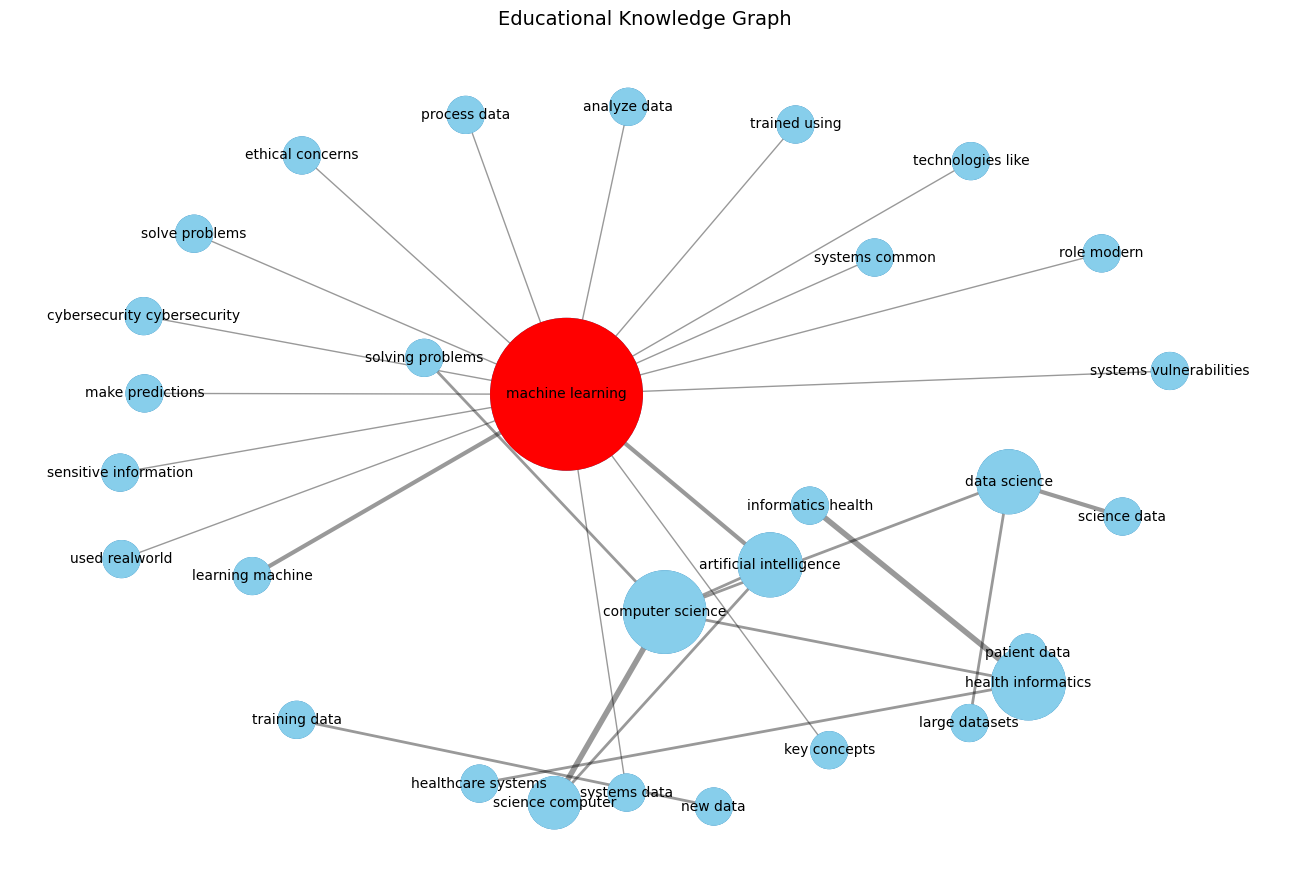

In [27]:
plt.figure(figsize=(13, 9))

pos = nx.spring_layout(G, k=1.5, seed=42)
degree = dict(G.degree())

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=[max(degree[node], 1) * 700 for node in G.nodes()],
    node_shape="o"
)

node_colors = [
    "red" if node == "machine learning" else "skyblue"
    for node in G.nodes()
]
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=[max(degree[node], 1) * 700 for node in G.nodes()],
    node_color=node_colors
)
nx.draw_networkx_edges(
    G,
    pos,
    width=[G[u][v]["weight"] for u, v in G.edges()],
    alpha=0.4
)
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

plt.title("Educational Knowledge Graph", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

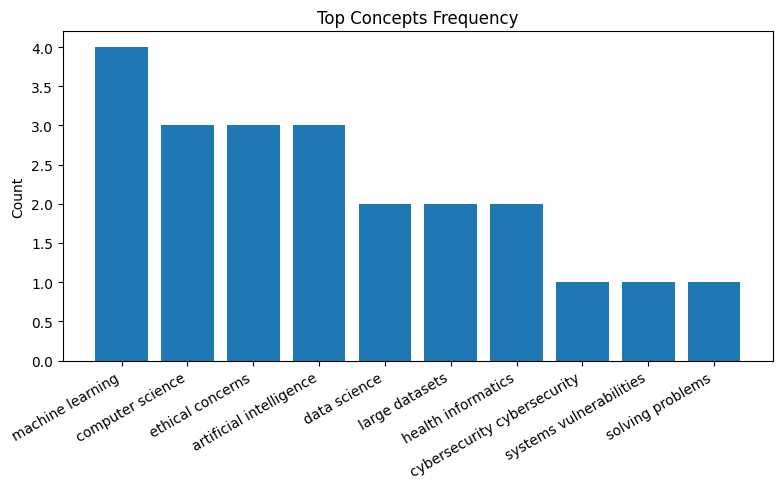

In [28]:
concept_counts = Counter()

for doc in cleaned_docs:
    for concept in concepts:
        if concept in doc:
            concept_counts[concept] += 1

top_concepts = concept_counts.most_common(10)

labels = [item[0] for item in top_concepts]
values = [item[1] for item in top_concepts]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.xticks(rotation=30, ha="right")
plt.title("Top Concepts Frequency")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

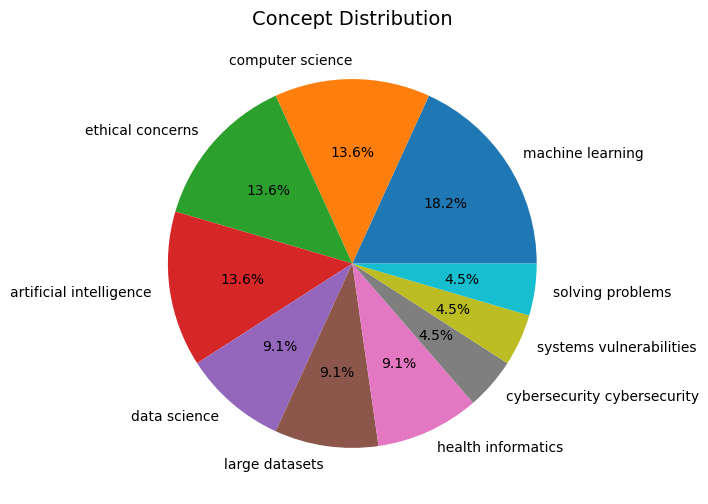

In [29]:
plt.figure(figsize=(7, 7))
plt.pie(values, labels=labels, autopct="%1.1f%%")
plt.title("Concept Distribution", fontsize=14)
plt.tight_layout()
plt.show()